# IFN680 Project 7: Improving DDPM - main_report

**Group 4** - Karan Rooprai (n12498122), Nhu Hieu Nguyen (n12194778)

This notebook reproduces **every number, table and figure in the report**. It trains nothing. It loads the two checkpoints `ddpm_linear.pth` and `ddpm_cosine.pth`, the evaluation classifier `DigitClassifier.pth`, the training record `DDPM_history.json` and the test split `mnist_custom_test.pt`, then samples both models and scores the samples. It draws tens of thousands of samples, so it takes about 9 minutes on the IFN680 GPU server and far longer on a CPU.

The hypothesis under test:

> *A cosine schedule allows a denoising diffusion probabilistic model to generate high-quality samples using fewer time steps than a linear schedule.*

Both models were trained at the tutorial's T = 1000 steps; "fewer time steps" is read as fewer **sampling** steps K (`DDPM_CosineSchedule.ipynb`, section 3.6 gives the reason). Every model, schedule and sampler is explained where it is built, in `DDPM_CosineSchedule.ipynb`, and the classifier in `DigitClassifier.ipynb`. The lead-ins here say what each output is and how to read it.

**Sections:** 1 Setup, 2 Test data, 3 The schedules, the network and the samplers, 4 Checkpoints and training records, 5 Figure 1, 6 How samples are scored, 7 Quality against the number of sampling steps, 8 Training time and quality against epochs, 9 The error at each noise level, 10 Where the schedules put their steps, 11 Figures 2 to 4, 12 Summary.

## 1 Setup

The libraries, the device and the seed, as in `DDPM_CosineSchedule.ipynb`, with one addition: TF32
is switched off, so every convolution runs in full float32 and the numbers below depend as little
as possible on which GPU, or CPU, runs the notebook. The palette cell keeps every figure in the
project's colours.

In [1]:
# The Week 9 tutorial's stack. json carries the training record to main_report.ipynb, and
# utils.make_grid lays out digit grids the way the tutorial's figures do.
import json
import platform

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import utils

# The brief asks for the IFN680 GPU environment. The same code runs on a CPU when no GPU is
# visible, so the notebook runs anywhere and every tensor is placed with .to(device).
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"device      : {device}")
print(f"python      : {platform.python_version()}")
print(f"torch       : {torch.__version__}")
print(f"torchvision : {torchvision.__version__}")
print(f"numpy       : {np.__version__}")

# One seed for everything that is not given its own: initial weights and random draws.
SEED = 0
np.random.seed(SEED)
_ = torch.manual_seed(SEED)

# Full float32 in every convolution. PyTorch lets recent NVIDIA GPUs run convolutions in the
# shorter TF32 format by default; switching it off makes the numbers below depend less on which
# GPU, or CPU, runs this notebook. Sampling repeats the network up to 1000 times per image, so
# small rounding differences would otherwise have many steps in which to grow.
torch.backends.cudnn.allow_tf32 = False

device      : cuda:0
python      : 3.12.14
torch       : 2.13.0+cu126
torchvision : 0.28.0+cu126
numpy       : 2.5.3


In [2]:
# One palette for every figure in the project, so the figures read as a set.
INK, ACCENT, WARM = "#1f2933", "#2f6f9f", "#c1553b"
MUTED, PALE, GREEN = "#7b8794", "#e8ecf1", "#3f7d58"
plt.rcParams.update({"font.size": 8, "axes.titlesize": 8, "axes.edgecolor": MUTED,
                     "axes.spines.top": False, "axes.spines.right": False})

## 2 Test data

The 10,000 test images and their labels, written by `DDPM_CosineSchedule.ipynb` (section 2).
Neither model saw them in training. The class counts matter in section 6: samples are drawn under
test labels, so every real and generated set compared there has the same class mix.

In [3]:
# The test split, written by DDPM_CosineSchedule.ipynb (section 2). This notebook is the only
# place it is scored. The image size and the number of classes are read from it.
test_data = torch.load("mnist_custom_test.pt", weights_only=True)
test_images, test_labels = test_data["test_images"], test_data["test_labels"]
image_size, n_class = test_images.shape[-1], int(test_labels.max()) + 1
labels_np = test_labels.numpy()
print(f"test_images : {tuple(test_images.shape)}, {test_images.dtype}")
print(f"test class counts : {np.bincount(labels_np, minlength=n_class).tolist()}")
print(f"pixels exactly 1.0 : {(test_images == 1).float().mean():.3f}")

test_images : (10000, 1, 20, 20), torch.float32
test class counts : [980, 1135, 1032, 1010, 982, 892, 958, 1028, 974, 1009]
pixels exactly 1.0 : 0.700


## 3 The schedules, the network and the samplers

The definitions below are byte for byte those of `DDPM_CosineSchedule.ipynb`, so the checkpoints
are read by the code that trained them. First the two schedules: the tutorial's `extract` and
`linear_beta_schedule`, then `cosine_beta_schedule` (section 3 there).

In [4]:
# Supplied by Tutorial 9.3 and reproduced unchanged. extract() picks each image's schedule
# value at its own step t, and linear_beta_schedule() is the baseline schedule under test.
def extract(a, t, x_shape):
    """
    Extracts coefficients at specified timesteps, then reshapes to [batch_size, 1, 1, 1] for broadcasting purposes 
    (piecewise multiplication with the noise image)
    a: Tensor of shape (num_timesteps) (e.g. alpha_bar)
    t: Tensor of shape (batch_size) with timestep indices
    """    
    batch_size = t.shape[0]
    out = a.gather(-1, t).reshape(batch_size, *((1,) * (len(x_shape) - 1)))
    return out


timesteps = 1000


def linear_beta_schedule(timesteps, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start,beta_end, timesteps)

In [5]:
# The schedule under test, written from Nichol and Dhariwal (2021), eq. 17: alpha_bar follows
# a squared cosine of t/T, offset by s = 0.008, and each beta is recovered as
# 1 - alpha_bar(t) / alpha_bar(t-1). Double precision, because near t = T this divides two very
# small numbers; beta is clipped at 0.999 because alpha_bar(T) is 0, which would make it 1.
def cosine_beta_schedule(timesteps, s=0.008):
    steps = torch.linspace(0, 1, timesteps + 1, dtype=torch.float64)
    f = torch.cos((steps + s) / (1 + s) * torch.pi / 2) ** 2
    alpha_bar = f / f[0]
    betas = 1 - alpha_bar[1:] / alpha_bar[:-1]
    return torch.clip(betas, max=0.999).float()

One dictionary of arrays per schedule (section 3.2 there), and the tutorial's `q_sample`
(section 3.3 there), which section 9 uses to noise real test images.

In [6]:
# One dictionary per schedule holds the three arrays the tutorial keeps as globals, so both
# schedules can be used side by side. alpha_bar is the running product of the alphas.
def make_schedule(betas):
    betas = betas.to(device)
    alphas = 1.0 - betas
    return {"betas": betas, "alphas": alphas, "alpha_bars": torch.cumprod(alphas, dim=0)}


SCHEDULE_FUNCTIONS = {"linear": linear_beta_schedule, "cosine": cosine_beta_schedule}
schedules = {name: make_schedule(build(timesteps)) for name, build in SCHEDULE_FUNCTIONS.items()}
for name, schedule in schedules.items():
    betas, alpha_bars = schedule["betas"], schedule["alpha_bars"]
    print(f"{name:6s} | beta from {betas[0]:.6f} to {betas[-1]:.4f} | alpha_bar from "
          f"{alpha_bars[0]:.6f} down to {alpha_bars[-1]:.2e}")
    # alpha_bar must fall at every step, or the process would un-noise the image somewhere
    assert bool((alpha_bars[1:] < alpha_bars[:-1]).all())

linear | beta from 0.000100 to 0.0200 | alpha_bar from 0.999900 down to 4.04e-05
cosine | beta from 0.000041 to 0.9990 | alpha_bar from 0.999959 down to 2.43e-09


In [7]:
# The tutorial's q_sample with one change: the schedule is an argument instead of a global.
# It jumps straight from a clean image x0 to step t:
# x_t = sqrt(alpha_bar_t) * x0 + sqrt(1 - alpha_bar_t) * noise.
def q_sample(x0, t, schedule, noise=None):
    if noise is None:
        noise = torch.randn_like(x0).to(device)
    alpha_bars = schedule["alpha_bars"]
    sqrt_alpha_bar = torch.sqrt(extract(alpha_bars,t,x0.shape))
    sqrt_one_minus_alpha_bar = torch.sqrt(extract(1-alpha_bars,t,x0.shape))
    return sqrt_alpha_bar*x0 + noise*sqrt_one_minus_alpha_bar

The tutorial's network, `ConvBlock` and `UNet_cond`, unchanged (section 4 there).

In [8]:
# Supplied by Tutorial 9.3 and reproduced unchanged: two 3 x 3 convolutions with ReLU, the
# building block of every level of the U-Net.
channels = 1 # for MNIST

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(),
        )
    def forward(self, x):
        return self.net(x)

In [9]:
# Supplied by Tutorial 9.3 (its solution) and reproduced unchanged: the conditional U-Net.
# The step t (divided by T) and the class each become 32 numbers, summed into cond_emb and
# added at every level through a 1 x 1 convolution.
class UNet_cond(nn.Module):
    def __init__(self, ch=32, n_classes=10):
        super().__init__()
        # encoder
        self.enc1 = ConvBlock(channels, ch)
        self.enc2 = ConvBlock(ch, ch*2)
        # bottleneck
        self.bot = ConvBlock(ch*2, ch*2)
        # decoder
        self.dec2 = ConvBlock(ch*2 + ch*2, ch)
        self.dec1 = ConvBlock(ch + ch, ch)
        # final
        self.final = nn.Conv2d(ch, channels, 1)

        # timestep embedding
        self.time_mlp = nn.Sequential(
            nn.Linear(1, ch),
            nn.ReLU(),
            nn.Linear(ch, ch)
        )

        # class embedding
        self.class_emb =  nn.Embedding(n_classes,ch)

        # projections to match channel dims
        self.to_e1 = nn.Conv2d(ch, ch, 1)
        self.to_e2 = nn.Conv2d(ch, ch*2, 1)
        self.to_b  = nn.Conv2d(ch, ch*2, 1)
        self.to_d2 = nn.Conv2d(ch, ch, 1)
        self.to_d1 = nn.Conv2d(ch, ch, 1)

        self.pool = nn.AvgPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x, t, y):        
        t = t.float().unsqueeze(-1) / timesteps
        t_emb = self.time_mlp(t).unsqueeze(-1).unsqueeze(-1)  
        
        y_emb = self.class_emb(y).unsqueeze(-1).unsqueeze(-1)
        # print(t_emb.shape)
        # print(y_emb.shape)

        cond_emb = t_emb + y_emb

        e1 = self.enc1(x) + self.to_e1(cond_emb)
        e2 = self.enc2(self.pool(e1)) + self.to_e2(cond_emb)

        b = self.bot(self.pool(e2)) + self.to_b(cond_emb)

        d2 = self.upsample(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2) + self.to_d2(cond_emb)

        d1 = self.upsample(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1) + self.to_d1(cond_emb)

        return self.final(d1)

The samplers (section 6 there). `sampling_steps(K)` lists the K steps a sampler visits, and
`p_sample_cDDPM` is the tutorial's reverse step, able to skip steps, with its clean-image estimate
clipped to the data range.

In [10]:
# Which of the 1000 steps a K-step sampler visits: K evenly spaced values from the first step
# to the last, rounded to whole steps (Nichol and Dhariwal, section 4). K = 1000 visits every
# step, which is the tutorial's loop.
def sampling_steps(n_steps):
    return np.round(np.linspace(0, timesteps - 1, n_steps)).astype(int).tolist()


for n_steps in (10, 20):
    print(f"K = {n_steps} visits steps {sampling_steps(n_steps)}")

K = 10 visits steps [0, 111, 222, 333, 444, 555, 666, 777, 888, 999]
K = 20 visits steps [0, 53, 105, 158, 210, 263, 315, 368, 421, 473, 526, 578, 631, 684, 736, 789, 841, 894, 946, 999]


In [11]:
# The tutorial's reverse step (p_sample_cDDPM), able to jump from step t_index back to any
# earlier step prev_index, with beta recomputed from the two alpha_bars (the tutorial's beta_t
# when prev_index = t_index - 1). It is written in its x0 form: the noise estimate gives a
# clean-image estimate x0_hat, and the step is a weighted average of x0_hat and x_t. Unclipped,
# this is the tutorial's update (checked in DDPM_CosineSchedule.ipynb, section 6.4); clipping
# x0_hat to the data range stops one bad noise estimate from throwing the image off scale
# (DDPM_CosineSchedule.ipynb, section 6.5).
@torch.no_grad()
def p_sample_cDDPM(model, x_t, t_index, y, schedule, prev_index, z, clip=True):
    t = torch.full((x_t.shape[0],), t_index, device=x_t.device, dtype=torch.long)
    alpha_bar = schedule["alpha_bars"][t_index]
    alpha_bar_prev = (schedule["alpha_bars"][prev_index] if prev_index >= 0
                      else alpha_bar.new_ones(()))
    beta = 1 - alpha_bar / alpha_bar_prev
    alpha = 1 - beta
    pred_noise = model(x_t, t, y)
    x0_hat = (x_t - (1 - alpha_bar).sqrt() * pred_noise) / alpha_bar.sqrt()
    if clip:
        x0_hat = x0_hat.clamp(-1, 1)
    mean = (alpha_bar_prev.sqrt() * beta / (1 - alpha_bar) * x0_hat
            + alpha.sqrt() * (1 - alpha_bar_prev) / (1 - alpha_bar) * x_t)
    # the last step adds no noise, as in the tutorial's z = 0 at t_index == 0
    return mean + beta.sqrt() * z if prev_index >= 0 else mean

The deterministic DDIM step, and the loop that runs either sampler from seeded noise.
`generate` draws large sets in chunks of 1,000 and returns them in [0, 1].

In [12]:
# DDIM (Song et al., 2021): the same network and the same x0_hat, but a deterministic step that
# moves x0_hat to the earlier step's noise level and reuses the noise estimate instead of
# drawing fresh noise. The estimate is recomputed from the clipped x0_hat so the two agree.
@torch.no_grad()
def ddim_step(model, x_t, t_index, y, schedule, prev_index, clip=True):
    t = torch.full((x_t.shape[0],), t_index, device=x_t.device, dtype=torch.long)
    alpha_bar = schedule["alpha_bars"][t_index]
    alpha_bar_prev = (schedule["alpha_bars"][prev_index] if prev_index >= 0
                      else alpha_bar.new_ones(()))
    pred_noise = model(x_t, t, y)
    x0_hat = (x_t - (1 - alpha_bar).sqrt() * pred_noise) / alpha_bar.sqrt()
    if clip:
        x0_hat = x0_hat.clamp(-1, 1)
        pred_noise = (x_t - alpha_bar.sqrt() * x0_hat) / (1 - alpha_bar).sqrt()
    return alpha_bar_prev.sqrt() * x0_hat + (1 - alpha_bar_prev).sqrt() * pred_noise

In [13]:
# The tutorial's sampling loop over the steps sampling_steps lists: start from pure noise and step
# down to 0. Every random draw comes from one seeded CPU generator and is then moved to the
# device, so a seed gives the same samples on any machine and both schedules start alike.
@torch.no_grad()
def p_sample_loop_cDDPM(model, y, schedule, n_steps=timesteps, sampler="ddpm", seed=1337,
                        clip=True):
    model.eval()
    generator = torch.Generator().manual_seed(seed)
    x = torch.randn(y.shape[0], channels, image_size, image_size, generator=generator).to(device)
    steps = sampling_steps(n_steps)
    for i in reversed(range(len(steps))):
        prev_index = steps[i - 1] if i > 0 else -1
        if sampler == "ddim":
            x = ddim_step(model, x, steps[i], y, schedule, prev_index, clip)
        else:
            z = torch.randn(x.shape, generator=generator).to(device)
            x = p_sample_cDDPM(model, x, steps[i], y, schedule, prev_index, z, clip)
    return x.clamp(-1,1)


# Large sets are drawn in chunks, chunk k with seed + k, and returned in [0, 1] on the CPU.
def generate(model, labels, schedule, n_steps, sampler, seed=1337, batch_size=1000):
    parts = []
    for number, start in enumerate(range(0, len(labels), batch_size)):
        y = labels[start:start + batch_size].to(device)
        x = p_sample_loop_cDDPM(model, y, schedule, n_steps, sampler, seed + number)
        parts.append(((x + 1) / 2).cpu())
    return torch.cat(parts)

The evaluation classifier (`DigitClassifier.ipynb`, section 3). `features()` returns its
128-unit layer.

In [14]:
# The evaluation classifier, in the style of lecture 9 p42's: two convolution blocks and a
# 128-unit layer. features() returns that layer, the space the Frechet distances use. It
# inverts each image first (1 - x), so strokes are bright on black as in the MNIST this design
# comes from, and the zero padding at the border matches the background.
class DigitClassifier(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 32x10x10
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 64x5x5
            nn.Flatten(),
            nn.Linear(64 * 5 * 5, 128), nn.ReLU(),
        )
        self.output_layer = nn.Linear(128, num_classes)

    def features(self, x):
        return self.feature_extractor(1 - x)

    def forward(self, x):
        return self.output_layer(self.features(x))

## 4 Checkpoints and training records

From `DDPM_history.json`: where the models were trained, the settings both schedules share, and
for each schedule the seconds per epoch, the minutes per training run and each seed's final
training loss. Then the two checkpoints the brief asks for, one per schedule, each holding the
final model of every seed and seed 0's earlier snapshots, and the classifier. The printed keys
and parameter counts identify what was loaded.

In [15]:
# How the models were trained, from the record DDPM_CosineSchedule.ipynb saved (section 5.6).
# Every setting below is read from the file, never retyped.
with open("DDPM_history.json") as handle:
    history = json.load(handle)
assert history["timesteps"] == timesteps
n_channels_unet, SEEDS = history["n_channels_unet"], history["seeds"]
print(f"trained on {history['device']} ({history['gpu']}), torch {history['torch']}")
print(f"epochs {history['epochs']} | batch size {history['batch_size']} | "
      f"learning rate {history['lr']} | seeds {SEEDS} | {history['n_train']:,} training images")
seconds_per_epoch = {}
for name in SCHEDULE_FUNCTIONS:
    runs = [history["runs"][f"{name}_seed_{seed}"] for seed in SEEDS]
    seconds_per_epoch[name] = float(np.mean([run["seconds"] for run in runs]))
    print(f"record | {name} | seconds per epoch {seconds_per_epoch[name]:.2f} | minutes per run "
          + " ".join(f"{sum(run['seconds']) / 60:.1f}" for run in runs)
          + " | final training loss " + " ".join(f"{run['loss'][-1]:.4f}" for run in runs))

trained on cuda:0 (NVIDIA A16-4Q), torch 2.13.0+cu126
epochs 150 | batch size 128 | learning rate 0.0002 | seeds [0, 1, 2] | 60,000 training images
record | linear | seconds per epoch 7.87 | minutes per run 19.7 19.6 19.6 | final training loss 0.0283 0.0283 0.0287
record | cosine | seconds per epoch 7.86 | minutes per run 19.7 19.6 19.6 | final training loss 0.0492 0.0495 0.0493


In [16]:
# The two checkpoints the brief asks for, one per schedule. Each holds plain CPU state_dicts:
# the final model of every seed ("seed_0", ...) and seed 0's earlier snapshots ("epoch_10", ...).
def load_unet(state):
    network = UNet_cond(ch=n_channels_unet, n_classes=n_class).to(device)
    network.load_state_dict(state)
    return network.eval()


def parameter_count(module):
    return sum(p.numel() for p in module.parameters())


checkpoints = {name: torch.load(f"ddpm_{name}.pth", map_location="cpu", weights_only=True)
               for name in SCHEDULE_FUNCTIONS}
models = {(name, seed): load_unet(checkpoints[name][f"seed_{seed}"])
          for name in SCHEDULE_FUNCTIONS for seed in SEEDS}
# The measuring instrument, trained in DigitClassifier.ipynb.
classifier = DigitClassifier(n_class).to(device)
_ = classifier.load_state_dict(torch.load("DigitClassifier.pth", map_location="cpu",
                                          weights_only=True))
_ = classifier.eval()
for name, checkpoint in checkpoints.items():
    print(f"ddpm_{name}.pth | {', '.join(checkpoint)}")
print(f"parameters | U-Net {parameter_count(models['linear', SEEDS[0]]):,} | "
      f"classifier {parameter_count(classifier):,}")

ddpm_linear.pth | seed_0, seed_1, seed_2, epoch_10, epoch_25, epoch_50, epoch_100
ddpm_cosine.pth | seed_0, seed_1, seed_2, epoch_10, epoch_25, epoch_50, epoch_100
parameters | U-Net 221,569 | classifier 225,034


## 5 Figure 1: the two 12 x 10 grids

Twelve samples per digit with the digits as rows, the brief's layout, from each schedule's seed-0
model with the tutorial's full 1000-step sampler. Both grids start from the same noise, so the two
images in the same place differ only by the model. `classify` returns the classifier's verdict on each
image; it is used here and in every later section.

In [17]:
# The classifier's verdict on images drawn as given classes: whether its top choice is that
# class. Returned per image, so a rate can be split by class or resampled.
def classify(images, labels, batch_size=2000):
    correct = []
    with torch.no_grad():
        for start in range(0, len(images), batch_size):
            logits = classifier(images[start:start + batch_size].to(device))
            target = labels[start:start + batch_size].to(device)
            correct.append((logits.argmax(dim=1) == target).cpu())
    return torch.cat(correct).double().numpy()

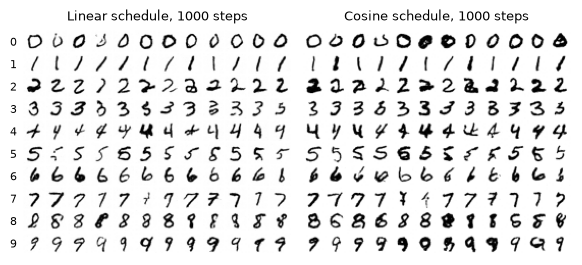

In [18]:
# Figure 1: each schedule's seed-0 model with the tutorial's full 1000-step sampler. Both grids
# start from the same noise (seed 1337, as in DDPM_CosineSchedule.ipynb, section 7), so the two
# images in the same place differ only by the model. Rows are the digits 0 to 9, twelve each.
sample_per_class = 12
grid_labels = torch.arange(n_class, device=device).repeat_interleave(sample_per_class)
grids = {name: (p_sample_loop_cDDPM(models[name, SEEDS[0]], grid_labels, schedules[name]) + 1) / 2
         for name in SCHEDULE_FUNCTIONS}
titles = {"linear": "Linear schedule", "cosine": "Cosine schedule"}
fig, axes = plt.subplots(1, 2, figsize=(7.1, 3.25), gridspec_kw={"wspace": 0.03})
for ax, (name, images) in zip(axes, grids.items()):
    ax.imshow(utils.make_grid(images.cpu(), nrow=sample_per_class, pad_value=1)[0], cmap="gray",
              vmin=0, vmax=1)
    ax.set_title(f"{titles[name]}, {timesteps} steps", fontsize=9)
    # The rows are the same digits in both grids, so only the left one is labelled.
    if ax is axes[0]:
        ax.set_yticks(12 + 22 * np.arange(n_class), [str(c) for c in range(n_class)], fontsize=8)
    else:
        ax.set_yticks([])
    ax.set_xticks([])
    ax.tick_params(length=0)
    for side in ("left", "bottom", "top", "right"):
        ax.spines[side].set_visible(False)
fig.savefig("figure_1_grids.pdf", bbox_inches="tight")
plt.show()

The share of each grid's 120 images the classifier reads as the digit they were drawn as.

In [19]:
# The share of each grid's 120 images the classifier reads as the digit they were drawn as.
grid_accuracy = {name: float(classify(images, grid_labels).mean())
                 for name, images in grids.items()}
for name, value in grid_accuracy.items():
    print(f"grid accuracy | {name} | {value:.4f} of {len(grids[name])} images")

grid accuracy | linear | 0.9583 of 120 images
grid accuracy | cosine | 0.9250 of 120 images


## 6 How samples are scored

Three measures, each computed on a set of samples drawn under test labels:

- **class consistency**: the share of samples the classifier reads as the intended digit;
- **Frechet distance (FD)** to real test digits in the classifier's 128-unit feature layer: the
  distance between two Gaussians fitted to the two clouds of feature vectors. It is 0 when the
  means and covariances match, and grows as the samples look less like real digits or vary more
  or less than they do. FID is the same quantity in the features of an ImageNet network; this
  one uses a network built for 20 x 20 digits;
- **spread**: within each class, the variety of the samples' features relative to real digits'.
  Near 1 matches real variety; well below 1 means the samples of a class look alike, the
  signature of mode collapse.

FD depends on how many images are compared and in which class mix. The test set is therefore split
into two disjoint sets of the same size and identical class counts. Samples are drawn under set A's
labels and compared with set B's real images, and set A's own real images against set B give the
**floor**, what a model drawing real digits would score.

In [20]:
# Two disjoint class-stratified sets of N_EVAL test images with identical class counts. Samples
# are drawn under set A's labels and compared with set B's real images, so every comparison has
# the same size and class mix; set A's own real images against set B give the floor.
N_EVAL = 1000
counts = np.bincount(labels_np, minlength=n_class)
quota = N_EVAL * counts / counts.sum()
per_class = np.floor(quota).astype(int)
# the classes with the largest remainders round up, so the counts add up to exactly N_EVAL
per_class[np.argsort(per_class - quota)[:N_EVAL - per_class.sum()]] += 1
rng = np.random.default_rng(SEED)
set_a, set_b = [], []
for c in range(n_class):
    members = rng.permutation(np.flatnonzero(labels_np == c))
    set_a.extend(members[:per_class[c]])
    set_b.extend(members[per_class[c]:2 * per_class[c]])
set_a, set_b = np.sort(set_a), np.sort(set_b)
eval_labels = test_labels[set_a]
labels_a, labels_b = labels_np[set_a], labels_np[set_b]
print(f"sets | A {len(set_a):,} | B {len(set_b):,} | per class {per_class.tolist()}")

sets | A 1,000 | B 1,000 | per class [98, 114, 103, 101, 98, 89, 96, 103, 97, 101]


The feature layer, the FD against set B (whose mean, covariance and covariance square root
are computed once) and the spread.

In [21]:
# The classifier's 128-unit feature layer, in float64, and the Frechet distance to one fixed
# reference set: the distance between two Gaussians fitted to the feature clouds, 0 when the
# means and covariances match. tr sqrt(C_ref C_x) comes from symmetric eigendecompositions, which
# stay real and exact; the reference's own square root is computed once and reused.
def features(images, batch_size=2000):
    with torch.no_grad():
        parts = [classifier.features(images[start:start + batch_size].to(device)).cpu()
                 for start in range(0, len(images), batch_size)]
    return torch.cat(parts).double().numpy()


def frechet_to(reference):
    mean_r, cov_r = reference.mean(axis=0), np.cov(reference, rowvar=False)
    values, vectors = np.linalg.eigh(cov_r)
    root_r = (vectors * np.sqrt(np.clip(values, 0, None))) @ vectors.T

    def distance(x):
        mean_x, cov_x = x.mean(axis=0), np.cov(x, rowvar=False)
        cross = np.sqrt(np.clip(np.linalg.eigvalsh(root_r @ cov_x @ root_r), 0, None)).sum()
        return float(((mean_x - mean_r) ** 2).sum() + np.trace(cov_r) + np.trace(cov_x)
                     - 2 * cross)
    return distance


# Set B is the reference for every distance and every spread.
real_b = features(test_images[set_b])
fd_to_b = frechet_to(real_b)
real_variety = [np.trace(np.cov(real_b[labels_b == c], rowvar=False)) for c in range(n_class)]


# Diversity: within each class, the total variance of a set's features over that of set B's
# real images, averaged over the classes. 1 matches real variety; well below 1 means the samples
# of a class look alike, the signature of mode collapse.
def spread_ratio(values):
    return float(np.mean([np.trace(np.cov(values[labels_a == c], rowvar=False)) / real_variety[c]
                          for c in range(n_class)]))

The reference values: the classifier's accuracy on all 10,000 real test images, and set A's real
images scored exactly as a sample set will be.

A **paired bootstrap** then turns one FD difference into an interval. Sample i of a linear set and
sample i of the matching cosine set share their label and their starting noise, so both sets are
resampled with the same indices and the difference recomputed each time. The middle 95% of the
resampled differences is the interval; if it excludes 0, the difference is not an accident of which
samples were drawn.

In [22]:
# The reference values: the classifier on every real test image, and set A's real images
# scored exactly as a sample set will be. A model that drew real digits would score these.
real_accuracy = float(classify(test_images, test_labels).mean())
real_a = features(test_images[set_a])
floor = fd_to_b(real_a)
real_a_accuracy = float(classify(test_images[set_a], eval_labels).mean())
print(f"classifier | all {len(test_labels):,} real test images | accuracy {real_accuracy:.4f}")
print(f"floor | real set A against set B | FD {floor:.2f} | accuracy {real_a_accuracy:.4f} | "
      f"spread {spread_ratio(real_a):.3f}")

classifier | all 10,000 real test images | accuracy 0.9914
floor | real set A against set B | FD 7.65 | accuracy 0.9970 | spread 0.982


In [23]:
# A paired bootstrap for a difference in FD, cosine minus linear. Sample i of a linear set and
# sample i of the matching cosine set share their label and their starting noise, so both sets
# are resampled with the same indices, RESAMPLES times, and the middle 95% of the recomputed
# differences is the interval. A fresh generator per call keeps it independent of cell order.
RESAMPLES = 1000


def fd_gap_interval(linear_features, cosine_features, seed=SEED):
    rng = np.random.default_rng(seed)
    gaps = []
    for _ in range(RESAMPLES):
        pick = rng.integers(0, len(linear_features), len(linear_features))
        gaps.append(fd_to_b(cosine_features[pick]) - fd_to_b(linear_features[pick]))
    low, high = np.percentile(gaps, [2.5, 97.5])
    return float(low), float(high)

## 7 Quality against the number of sampling steps

The experiment behind the hypothesis. Each model is sampled with K = 10, 20, 50, 100 and 250 steps by
both samplers, and with the tutorial's 1000-step sampler as the full-quality reference. DDIM is not
run at 1000 steps: it exists to take fewer, and the reference is the tutorial's own sampler. Seed
0's models are sampled at every K, the models of the other two seeds at every reduced K. Every set
uses set A's labels and the same starting noise, so each linear set is paired with a cosine set.

Each printed line gives the seed, the sampler, K, and for each schedule the FD (lower is better),
the class consistency and the spread.

In [24]:
# The sampling budgets K and the two samplers. Seed 0's models are sampled at every K, and the
# tutorial's own 1000-step sampler is the full-quality reference; the models of the other seeds
# are sampled at every reduced K, the budgets the decision rule is about.
STEP_COUNTS = (10, 20, 50, 100, 250, 1000)
REDUCED = [n_steps for n_steps in STEP_COUNTS if n_steps < timesteps]
SAMPLERS = ("ddpm", "ddim")
plan = [(SEEDS[0], "ddpm", timesteps)] + [(seed, sampler, n_steps) for seed in SEEDS
                                          for sampler in SAMPLERS for n_steps in REDUCED]
print(f"{len(plan)} sample sets per schedule, {N_EVAL:,} images each")

31 sample sets per schedule, 1,000 images each


In [25]:
# Every sample set, scored as it is drawn. The features are kept for the bootstrap, and seed 0's
# images for Figure 3. Both schedules use the same labels and the same starting noise.
scores, kept_features, kept_images = {}, {}, {}
for seed, sampler, n_steps in plan:
    cells = []
    for name in SCHEDULE_FUNCTIONS:
        images = generate(models[name, seed], eval_labels, schedules[name], n_steps, sampler)
        key = (name, seed, sampler, n_steps)
        kept_features[key] = features(images)
        scores[key] = {"fd": fd_to_b(kept_features[key]),
                       "accuracy": float(classify(images, eval_labels).mean()),
                       "spread": spread_ratio(kept_features[key])}
        if seed == SEEDS[0]:
            kept_images[key] = images
        cells.append(f"{name} FD {scores[key]['fd']:6.2f} accuracy "
                     f"{scores[key]['accuracy']:.4f} spread {scores[key]['spread']:.3f}")
    print(f"quality | seed {seed} | {sampler} | K={n_steps:4d} | " + " | ".join(cells))

quality | seed 0 | ddpm | K=1000 | linear FD  17.12 accuracy 0.9650 spread 0.959 | cosine FD  13.50 accuracy 0.9640 spread 1.075


quality | seed 0 | ddpm | K=  10 | linear FD 186.26 accuracy 0.9130 spread 0.632 | cosine FD  85.35 accuracy 0.8960 spread 0.944


quality | seed 0 | ddpm | K=  20 | linear FD  61.77 accuracy 0.9470 spread 0.783 | cosine FD  26.55 accuracy 0.9480 spread 0.997


quality | seed 0 | ddpm | K=  50 | linear FD  26.55 accuracy 0.9670 spread 0.884 | cosine FD  17.25 accuracy 0.9420 spread 1.036


quality | seed 0 | ddpm | K= 100 | linear FD  18.67 accuracy 0.9570 spread 0.952 | cosine FD  15.61 accuracy 0.9430 spread 1.075


...

quality | seed 2 | ddim | K=  10 | linear FD  37.96 accuracy 0.9640 spread 0.853 | cosine FD  33.03 accuracy 0.9010 spread 1.227


quality | seed 2 | ddim | K=  20 | linear FD  26.62 accuracy 0.9440 spread 0.963 | cosine FD  21.77 accuracy 0.9260 spread 1.182


quality | seed 2 | ddim | K=  50 | linear FD  23.18 accuracy 0.9410 spread 1.023 | cosine FD  21.06 accuracy 0.9260 spread 1.164


quality | seed 2 | ddim | K= 100 | linear FD  22.56 accuracy 0.9400 spread 1.040 | cosine FD  21.32 accuracy 0.9260 spread 1.160


quality | seed 2 | ddim | K= 250 | linear FD  22.29 accuracy 0.9380 spread 1.050 | cosine FD  21.47 accuracy 0.9250 spread 1.158


### 7.1 The decision rule

The rule was fixed before any sample was scored. At each reduced K and for each sampler, a schedule
counts as **better** only if three things hold together: its FD is lower at seed 0, the paired 95%
interval of the difference excludes 0, and its FD is lower again at every other seed. Otherwise
that step count is **unclear**. The `verdict` lines group the step counts by outcome. The last line
compares the two models at the full 1000 steps, where the hypothesis makes no claim but every
reduced K is measured against it.

In [26]:
# The decision rule, fixed before any sample was scored. At a reduced K, for one sampler, a
# schedule is "better" when its FD is lower at seed 0 with the paired interval excluding 0, and
# lower again at every other seed. Anything else is "unclear".
def compare(sampler, n_steps):
    gaps = [scores["cosine", seed, sampler, n_steps]["fd"]
            - scores["linear", seed, sampler, n_steps]["fd"] for seed in SEEDS]
    low, high = fd_gap_interval(kept_features["linear", SEEDS[0], sampler, n_steps],
                                kept_features["cosine", SEEDS[0], sampler, n_steps])
    if high < 0 and all(gap < 0 for gap in gaps):
        winner = "cosine"
    elif low > 0 and all(gap > 0 for gap in gaps):
        winner = "linear"
    else:
        winner = "unclear"
    return {"gaps": gaps, "low": low, "high": high, "winner": winner}


def listing(step_counts):
    return ", ".join(str(n_steps) for n_steps in step_counts) or "none"


decisions = {(sampler, n_steps): compare(sampler, n_steps)
             for sampler in SAMPLERS for n_steps in REDUCED}
for (sampler, n_steps), d in decisions.items():
    print(f"rule | {sampler} | K={n_steps:4d} | cosine minus linear FD {d['gaps'][0]:+.2f} "
          f"[{d['low']:+.2f}, {d['high']:+.2f}] | other seeds "
          + " ".join(f"{gap:+.2f}" for gap in d["gaps"][1:]) + f" | {d['winner']}")
for sampler in SAMPLERS:
    groups = {winner: [k for k in REDUCED if decisions[sampler, k]["winner"] == winner]
              for winner in ("cosine", "linear", "unclear")}
    print(f"verdict | {sampler} | cosine better at K = {listing(groups['cosine'])} | "
          f"linear better at K = {listing(groups['linear'])} | "
          f"unclear at K = {listing(groups['unclear'])}")
# At the full 1000 steps, seed 0 only: the hypothesis makes no claim here, but it is the
# baseline every reduced K is measured against.
full_fd = {name: scores[name, SEEDS[0], "ddpm", timesteps]["fd"] for name in SCHEDULE_FUNCTIONS}
full_low, full_high = fd_gap_interval(kept_features["linear", SEEDS[0], "ddpm", timesteps],
                                      kept_features["cosine", SEEDS[0], "ddpm", timesteps])
print(f"full steps | cosine minus linear FD {full_fd['cosine'] - full_fd['linear']:+.2f} "
      f"[{full_low:+.2f}, {full_high:+.2f}]")

rule | ddpm | K=  10 | cosine minus linear FD -100.91 [-111.11, -89.05] | other seeds -125.94 -120.97 | cosine
rule | ddpm | K=  20 | cosine minus linear FD -35.22 [-41.54, -28.39] | other seeds -13.18 -29.46 | cosine
rule | ddpm | K=  50 | cosine minus linear FD -9.30 [-13.84, -4.54] | other seeds +14.59 -2.90 | unclear
rule | ddpm | K= 100 | cosine minus linear FD -3.06 [-7.57, +1.53] | other seeds +17.78 +2.57 | unclear
rule | ddpm | K= 250 | cosine minus linear FD +0.31 [-3.64, +4.64] | other seeds +22.65 +1.28 | unclear
rule | ddim | K=  10 | cosine minus linear FD +57.33 [+44.97, +69.68] | other seeds +3.86 -4.93 | unclear
rule | ddim | K=  20 | cosine minus linear FD +6.89 [-0.42, +14.88] | other seeds +16.94 -4.85 | unclear
rule | ddim | K=  50 | cosine minus linear FD -1.17 [-7.22, +5.27] | other seeds +25.26 -2.12 | unclear
rule | ddim | K= 100 | cosine minus linear FD -2.14 [-7.76, +3.97] | other seeds +26.75 -1.24 | unclear
rule | ddim | K= 250 | cosine minus linear FD -2.7

full steps | cosine minus linear FD -3.61 [-7.70, +0.74]


### 7.2 How few steps are enough

Two step counts summarise each curve, both at seed 0 and against the 1000-step reference: the
fewest steps at which a schedule's FD comes within 10% of its own full-step FD, and the fewest at
which the cosine model's FD reaches the linear model's full-step FD.

In [27]:
# Two step counts that summarise each curve, at seed 0 and against the 1000-step reference: the
# fewest steps at which a schedule's FD is within 10% of its own full-step FD, and the fewest
# at which the cosine model's FD is at or below the linear model's full-step FD.
def fewest_steps(name, sampler, target):
    return next((k for k in REDUCED if scores[name, SEEDS[0], sampler, k]["fd"] <= target), None)


def as_steps(n_steps):
    return "at no reduced K" if n_steps is None else f"from K={n_steps}"


for sampler in SAMPLERS:
    own = {name: as_steps(fewest_steps(name, sampler, 1.1 * full_fd[name]))
           for name in SCHEDULE_FUNCTIONS}
    reach = as_steps(fewest_steps("cosine", sampler, full_fd["linear"]))
    print(f"fewest steps | {sampler} | within 10% of its own 1000-step FD: linear "
          f"{own['linear']}, cosine {own['cosine']} | cosine at or below linear's 1000-step "
          f"FD {reach}")

fewest steps | ddpm | within 10% of its own 1000-step FD: linear from K=100, cosine at no reduced K | cosine at or below linear's 1000-step FD from K=100
fewest steps | ddim | within 10% of its own 1000-step FD: linear at no reduced K, cosine at no reduced K | cosine at or below linear's 1000-step FD at no reduced K


### 7.3 A follow-up: the noise the last step leaves

Run after the rule gave its verdict, and not part of it. Figure 3 shows the linear model's DDPM
samples at few steps on a speckled background, and the cosine model's on a clean one. With K steps
the sampler's second-to-last step jumps from a step well above 0 straight to step 0 and adds noise
of variance $\beta = 1 - \bar\alpha_t / \bar\alpha_0$. The last step is told it is at step 0, where
almost no noise is expected, so it removes almost none of it. The linear schedule's
$\bar\alpha_t$ falls faster near the start, so that jump, and the noise, is larger.

Each line gives, per schedule, the standard deviation of that noise, the seed-0 FD from section 7
with the tutorial's variance $\beta$, and the FD of the same sampler, from the same starting noise,
with the smaller posterior variance of Ho et al. (2020),
$\tilde\beta = \frac{1 - \bar\alpha_{t'}}{1 - \bar\alpha_t}\,\beta$, which adds almost no noise on that
jump.

In [28]:
# A follow-up, run after the rule's verdict and not part of it. At K steps the DDPM sampler's
# second-to-last step jumps from step sampling_steps(K)[1] to step 0 and adds noise of variance
# beta = 1 - alpha_bar[t] / alpha_bar[0]; the last step, told it is at step 0 where almost no
# noise is expected, removes almost none of it. last_noise gives that noise's standard deviation.
def last_noise(schedule, n_steps):
    alpha_bars = schedule["alpha_bars"].double().cpu()
    return float((1 - alpha_bars[sampling_steps(n_steps)[1]] / alpha_bars[0]).sqrt())


# The same sampler with Ho et al.'s smaller posterior variance, beta_tilde =
# (1 - alpha_bar_prev) / (1 - alpha_bar) * beta, in place of the tutorial's beta: each step's
# noise z is scaled by sqrt(beta_tilde / beta) before p_sample_cDDPM adds it. The generator is
# seeded and drawn exactly as in generate, so each image starts from the same noise as before.
@torch.no_grad()
def generate_posterior(model, labels, schedule, n_steps, seed=1337):
    model.eval()
    generator = torch.Generator().manual_seed(seed)
    y = labels.to(device)
    x = torch.randn(len(y), channels, image_size, image_size, generator=generator).to(device)
    alpha_bars = schedule["alpha_bars"]
    steps = sampling_steps(n_steps)
    for i in reversed(range(len(steps))):
        prev_index = steps[i - 1] if i > 0 else -1
        z = torch.randn(x.shape, generator=generator).to(device)
        if prev_index >= 0:
            z = z * ((1 - alpha_bars[prev_index]) / (1 - alpha_bars[steps[i]])).sqrt()
        x = p_sample_cDDPM(model, x, steps[i], y, schedule, prev_index, z)
    return ((x.clamp(-1, 1) + 1) / 2).cpu()


assert len(eval_labels) <= 1000, "generate draws one chunk per 1,000 images; so must this"
for n_steps in REDUCED:
    cells = []
    for name in SCHEDULE_FUNCTIONS:
        images = generate_posterior(models[name, SEEDS[0]], eval_labels, schedules[name], n_steps)
        cells.append(f"{name} last-step noise {last_noise(schedules[name], n_steps):.3f} FD with "
                     f"beta {scores[name, SEEDS[0], 'ddpm', n_steps]['fd']:6.2f}, with beta_tilde "
                     f"{fd_to_b(features(images)):6.2f}")
    print(f"variance | K={n_steps:4d} | " + " | ".join(cells))

variance | K=  10 | linear last-step noise 0.355 FD with beta 186.26, with beta_tilde  42.40 | cosine last-step noise 0.185 FD with beta  85.35, with beta_tilde  30.64


variance | K=  20 | linear last-step noise 0.182 FD with beta  61.77, with beta_tilde  26.17 | cosine last-step noise 0.095 FD with beta  26.55, with beta_tilde  15.88


variance | K=  50 | linear last-step noise 0.079 FD with beta  26.55, with beta_tilde  19.35 | cosine last-step noise 0.043 FD with beta  17.25, with beta_tilde  15.22


variance | K= 100 | linear last-step noise 0.046 FD with beta  18.67, with beta_tilde  15.67 | cosine last-step noise 0.026 FD with beta  15.61, with beta_tilde  14.80


variance | K= 250 | linear last-step noise 0.024 FD with beta  15.27, with beta_tilde  14.37 | cosine last-step noise 0.015 FD with beta  15.58, with beta_tilde  15.10


## 8 Training time and quality against epochs

The schedule changes which noise level each training step uses, not the computation a step takes,
so the seconds per epoch of section 4 should match. What it can change is how many epochs a model
needs. Seed 0 kept snapshots of its weights during training, at the epochs listed in
`DDPM_history.json`. Each is sampled with DDIM at 50 steps under set A's labels and
scored as in section 7. The last line gives, for each schedule, the first epoch whose FD is within
10% of the final model's, and the training time that took.

In [29]:
# Quality against training, seed 0: every saved snapshot sampled with DDIM at EPOCH_STEPS steps
# under set A's labels. The last epoch is the final seed-0 model, already scored in section 7.
EPOCH_STEPS = 50
assert EPOCH_STEPS in REDUCED
epoch_list = history["snapshot_epochs"] + [history["epochs"]]
epoch_scores = {}
for epoch in epoch_list:
    cells = []
    for name in SCHEDULE_FUNCTIONS:
        if epoch == history["epochs"]:
            epoch_scores[name, epoch] = scores[name, SEEDS[0], "ddim", EPOCH_STEPS]
        else:
            snapshot = load_unet(checkpoints[name][f"epoch_{epoch}"])
            images = generate(snapshot, eval_labels, schedules[name], EPOCH_STEPS, "ddim")
            epoch_scores[name, epoch] = {"fd": fd_to_b(features(images)),
                                         "accuracy": float(classify(images, eval_labels).mean())}
        cells.append(f"{name} FD {epoch_scores[name, epoch]['fd']:6.2f} accuracy "
                     f"{epoch_scores[name, epoch]['accuracy']:.4f}")
    print(f"epochs | epoch {epoch:3d} | " + " | ".join(cells))
# The first snapshot whose FD is at most 1.1 times the final model's, and the training time
# that took at the measured seconds per epoch.
cells = []
for name in SCHEDULE_FUNCTIONS:
    final = epoch_scores[name, epoch_list[-1]]["fd"]
    reached = next(e for e in epoch_list if epoch_scores[name, e]["fd"] <= 1.1 * final)
    cells.append(f"{name} {reached} ({reached * seconds_per_epoch[name] / 60:.1f} min)")
print("epochs | within 10% of the final FD from epoch: " + ", ".join(cells))

epochs | epoch  10 | linear FD 237.65 accuracy 0.5130 | cosine FD 138.04 accuracy 0.6050


epochs | epoch  25 | linear FD  98.14 accuracy 0.7710 | cosine FD 129.32 accuracy 0.7550


epochs | epoch  50 | linear FD  44.72 accuracy 0.8610 | cosine FD  34.71 accuracy 0.8730


epochs | epoch 100 | linear FD  71.17 accuracy 0.9230 | cosine FD  28.74 accuracy 0.9370
epochs | epoch 150 | linear FD  28.48 accuracy 0.9550 | cosine FD  27.31 accuracy 0.9270
epochs | within 10% of the final FD from epoch: linear 150 (19.7 min), cosine 100 (13.1 min)


## 9 The error at each noise level

A model's training loss is its error averaged over steps t drawn evenly from 1000. The two schedules
put those steps at different noise levels, so their training losses average different mixes of
easy and hard questions and cannot be compared directly. Here both seed-0 models answer the same
questions: set A's real images noised at 20 evenly spaced steps t, with the same noise for both.
Each line gives, per schedule, the noise level at that step as log SNR and the mean squared error
of the predicted noise. Where almost no signal is left, $x_t$ is nearly the noise itself and
predicting the noise is easy.

In [30]:
# Each seed-0 model's noise-prediction error at 20 evenly spaced steps t, on set A's real images.
# At each step both schedules see the same images and the same noise; only the noise level that
# the schedule assigns to that step differs.
LOSS_STEPS = np.round(np.linspace(0, timesteps - 1, 20)).astype(int).tolist()
x0 = (test_images[set_a] * 2 - 1).to(device)
y0 = eval_labels.to(device)
step_loss, log_snr, signal_left = {name: [] for name in SCHEDULE_FUNCTIONS}, {}, {}
with torch.no_grad():
    for name, schedule in schedules.items():
        signal_left[name] = schedule["alpha_bars"].double().cpu().numpy()[LOSS_STEPS]
        log_snr[name] = np.log(signal_left[name] / (1 - signal_left[name]))
        for step in LOSS_STEPS:
            generator = torch.Generator().manual_seed(SEED + step)
            noise = torch.randn(x0.shape, generator=generator).to(device)
            t = torch.full((len(x0),), step, device=device, dtype=torch.long)
            predicted = models[name, SEEDS[0]](q_sample(x0, t, schedule, noise), t, y0)
            step_loss[name].append(float(((predicted - noise) ** 2).mean()))
for i, step in enumerate(LOSS_STEPS):
    print(f"loss | t={step:3d} | " + " | ".join(
        f"{name} log SNR {log_snr[name][i]:+6.2f} MSE {step_loss[name][i]:.4f}"
        for name in SCHEDULE_FUNCTIONS))

loss | t=  0 | linear log SNR  +9.21 MSE 0.4129 | cosine log SNR +10.09 MSE 0.4085
loss | t= 53 | linear log SNR  +3.37 MSE 0.1028 | cosine log SNR  +4.68 MSE 0.1386
loss | t=105 | linear log SNR  +2.05 MSE 0.0692 | cosine log SNR  +3.44 MSE 0.0992
loss | t=158 | linear log SNR  +1.19 MSE 0.0536 | cosine log SNR  +2.65 MSE 0.0808
loss | t=210 | linear log SNR  +0.53 MSE 0.0454 | cosine log SNR  +2.07 MSE 0.0683
loss | t=263 | linear log SNR  -0.05 MSE 0.0380 | cosine log SNR  +1.59 MSE 0.0596
loss | t=315 | linear log SNR  -0.58 MSE 0.0325 | cosine log SNR  +1.19 MSE 0.0537
loss | t=368 | linear log SNR  -1.11 MSE 0.0263 | cosine log SNR  +0.81 MSE 0.0489
loss | t=421 | linear log SNR  -1.64 MSE 0.0203 | cosine log SNR  +0.47 MSE 0.0450
loss | t=473 | linear log SNR  -2.18 MSE 0.0143 | cosine log SNR  +0.14 MSE 0.0403
loss | t=526 | linear log SNR  -2.76 MSE 0.0094 | cosine log SNR  -0.19 MSE 0.0368
loss | t=578 | linear log SNR  -3.37 MSE 0.0057 | cosine log SNR  -0.52 MSE 0.0337
loss

Three summaries per schedule: the mean over the 20 steps, an estimate of the training loss; the
error at the steps with less than 1% of the signal left against the others; and the two models
compared at the same noise level, over the range of log SNR both schedules cover.

In [31]:
# Three summaries. The mean over the 20 steps estimates the training loss, which draws t evenly.
# The split separates steps with less than 1% of the signal left from the rest. The matched
# comparison interpolates both curves (in log error) onto one grid of log SNR values inside the
# range both schedules cover, and divides the cosine model's error by the linear model's. It is
# reported separately above and below 1% signal: below it both errors are tiny, and a ratio of two
# tiny numbers would dominate an average while saying little about the images.
for name in SCHEDULE_FUNCTIONS:
    errors, noisy = np.array(step_loss[name]), signal_left[name] < 0.01
    print(f"loss | {name} | mean over the 20 steps {errors.mean():.4f} | {noisy.sum()} of 20 "
          f"steps below 0.01 signal, mean MSE there {errors[noisy].mean():.4f}, elsewhere "
          f"{errors[~noisy].mean():.4f}")
low = max(log_snr[name].min() for name in SCHEDULE_FUNCTIONS)
high = min(log_snr[name].max() for name in SCHEDULE_FUNCTIONS)
grid = np.linspace(low, high, 50)
# log SNR falls as t rises, so each curve is reversed to give np.interp rising x values
matched = {name: np.exp(np.interp(grid, log_snr[name][::-1], np.log(step_loss[name])[::-1]))
           for name in SCHEDULE_FUNCTIONS}
ratio = matched["cosine"] / matched["linear"]
threshold = np.log(0.01 / 0.99)  # the log SNR at which 1% of the signal is left
for side, part in (("above", grid >= threshold), ("below", grid < threshold)):
    print(f"loss | matched log SNR {side} {threshold:+.2f} | cosine over linear error: mean "
          f"{ratio[part].mean():.2f}, from {ratio[part].min():.2f} to {ratio[part].max():.2f} | "
          f"largest error linear {matched['linear'][part].max():.4f}, cosine "
          f"{matched['cosine'][part].max():.4f}")

loss | linear | mean over the 20 steps 0.0419 | 7 of 20 steps below 0.01 signal, mean MSE there 0.0007, elsewhere 0.0641
loss | cosine | mean over the 20 steps 0.0612 | 2 of 20 steps below 0.01 signal, mean MSE there 0.0020, elsewhere 0.0678
loss | matched log SNR above -4.60 | cosine over linear error: mean 1.00, from 0.83 to 1.40 | largest error linear 0.4129, cosine 0.3424
loss | matched log SNR below -4.60 | cosine over linear error: mean 4.55, from 1.52 to 7.43 | largest error linear 0.0021, cosine 0.0031


## 10 Where the schedules put their steps

The schedule facts the report quotes, recomputed from the schedules: the share of the 1000 steps
with less than 1% of the signal left, and how many of a 10-step sampler's steps fall there; the
signal left at a 10-step sampler's second step, and the weight $\sqrt{\bar\alpha}$ with which the
first clean-image estimate, made from pure noise, enters it; and the multiplier the tutorial's form
of the step puts on an error in the noise estimate at the first step (`DDPM_CosineSchedule.ipynb`,
section 6.5). The last line is the tutorial's linear schedule over a 100-step process (section 3.6
there).

In [32]:
# The schedule facts the report quotes (DDPM_CosineSchedule.ipynb, sections 3.5, 3.6 and 6.5).
# The weight is the share of the first clean-image estimate, made from pure noise, that the first
# step carries into the second state: sqrt(alpha_bar) there, since beta is close to 1.
steps_10 = sampling_steps(10)
for name, schedule in schedules.items():
    alpha_bars = schedule["alpha_bars"].double().cpu().numpy()
    gains = []
    for n_steps in (10, timesteps):
        first, second = sampling_steps(n_steps)[-1], sampling_steps(n_steps)[-2]
        alpha = alpha_bars[first] / alpha_bars[second]
        gains.append((1 - alpha) / (np.sqrt(alpha) * np.sqrt(1 - alpha_bars[first])))
    noisy_10 = int(sum(alpha_bars[step] < 0.01 for step in steps_10))
    print(f"schedule | {name} | below 0.01: {(alpha_bars < 0.01).mean():.1%} of steps, "
          f"{noisy_10} of K=10's | alpha_bar at t={steps_10[-2]} {alpha_bars[steps_10[-2]]:.5f}, "
          f"weight {np.sqrt(alpha_bars[steps_10[-2]]):.3f} | first-step multiplier K=10 "
          f"{gains[0]:,.2f}, K={timesteps} {gains[1]:,.2f}")
short_end = torch.cumprod(1 - linear_beta_schedule(100), dim=0)[-1]
print(f"schedule | linear over a 100-step process ends at alpha_bar {short_end:.3f}")

schedule | linear | below 0.01: 32.7% of steps, 3 of K=10's | alpha_bar at t=888 0.00034, weight 0.018 | first-step multiplier K=10 2.54, K=1000 0.02
schedule | cosine | below 0.01: 6.5% of steps, 1 of K=10's | alpha_bar at t=888 0.02963, weight 0.172 | first-step multiplier K=10 3,492.67, K=1000 31.59
schedule | linear over a 100-step process ends at alpha_bar 0.364


## 11 Figures 2 to 4

Figures 1 and 2 are the report's. Figures 3 and 4 show the same results from other angles and
are not reproduced in the two-page report.

**Figure 2.** FD (top) and class consistency (bottom) against K at seed 0, solid for DDPM and
dashed for DDIM. The other seeds' FDs at each reduced K are the small dots. The dotted lines are
set A's real images, the floor of section 6.

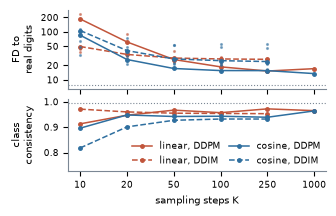

In [33]:
# Figure 2: FD (top) and class consistency (bottom) at seed 0 for each number of sampling steps
# K, solid for DDPM and dashed for DDIM. The other seeds' FDs at each reduced K are the small
# dots; the dotted lines are set A's real images, the floor of section 6. The step counts are
# evenly spaced, being the six budgets compared rather than a continuum, and FD is on a log
# scale so the K = 10 values do not flatten the differences at larger K.
COLOURS = {"linear": WARM, "cosine": ACCENT}
LINES = {"ddpm": "-", "ddim": "--"}
place = {n_steps: i for i, n_steps in enumerate(STEP_COUNTS)}
fig, (ax_fd, ax_acc) = plt.subplots(2, 1, figsize=(3.4, 2.2), sharex=True,
                                    gridspec_kw={"height_ratios": (1.1, 1)})
for name, colour in COLOURS.items():
    for sampler, line in LINES.items():
        used = [k for k in STEP_COUNTS if (name, SEEDS[0], sampler, k) in scores]
        x = [place[k] for k in used]
        ax_fd.plot(x, [scores[name, SEEDS[0], sampler, k]["fd"] for k in used], "o" + line,
                   color=colour, ms=2.5, lw=1.1, label=f"{name}, {sampler.upper()}")
        ax_acc.plot(x, [scores[name, SEEDS[0], sampler, k]["accuracy"] for k in used],
                    "o" + line, color=colour, ms=2.5, lw=1.1)
        for seed in SEEDS[1:]:
            ax_fd.plot([place[k] for k in REDUCED],
                       [scores[name, seed, sampler, k]["fd"] for k in REDUCED], ".",
                       color=colour, ms=2.5, alpha=0.5)
ax_fd.axhline(floor, color=MUTED, lw=0.8, ls=":")
ax_acc.axhline(real_a_accuracy, color=MUTED, lw=0.8, ls=":")
ax_fd.set_yscale("log")
ax_fd.set_yticks([10, 20, 50, 100, 200], ["10", "20", "50", "100", "200"])
ax_fd.set_ylabel("FD to\nreal digits", fontsize=7.5)
ax_acc.set_ylabel("class\nconsistency", fontsize=7.5)
# Room below the lowest consistency for the key, which sits under the curves from K = 50 on.
lowest = min(v["accuracy"] for v in scores.values())
ax_acc.set_ylim(lowest - 0.5 * (1 - lowest), 1.01)
fig.align_ylabels((ax_fd, ax_acc))
ax_acc.set_xticks(range(len(STEP_COUNTS)), [str(k) for k in STEP_COUNTS])
ax_acc.set_xlabel("sampling steps K", fontsize=7.5)
for ax in (ax_fd, ax_acc):
    ax.tick_params(labelsize=6.5)
    ax.minorticks_off()
# The key sits in the lower panel's bottom right, which the curves leave empty, so the FD panel
# needs no headroom for it.
ax_acc.legend(*ax_fd.get_legend_handles_labels(), frameon=False, fontsize=6.5, loc="lower right",
              ncol=2, handlelength=2.2, columnspacing=1.0, borderaxespad=0.2)
plt.tight_layout(h_pad=0.4)
fig.savefig("figure_2_steps.pdf", bbox_inches="tight")
plt.show()

**Figure 3.** What fewer steps look like: one DDPM sample per digit from each seed-0 model at
K = 10, 20, 50 and 1000. Every row starts from the same noise.

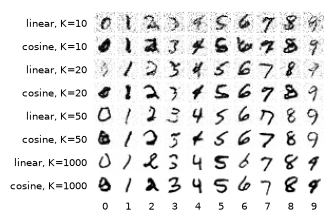

In [34]:
# Figure 3: what fewer steps look like. For each K, one DDPM sample per digit from each seed-0
# model: the first image of each class in set A, so every row starts from the same noise.
SHOWN_STEPS = (10, 20, 50, timesteps)
first_of_class = [int(np.flatnonzero(labels_a == c)[0]) for c in range(n_class)]
rows, row_names = [], []
for n_steps in SHOWN_STEPS:
    for name in SCHEDULE_FUNCTIONS:
        rows.append(kept_images[name, SEEDS[0], "ddpm", n_steps][first_of_class])
        row_names.append(f"{name}, K={n_steps}")
fig, ax = plt.subplots(figsize=(3.4, 2.9))
ax.imshow(utils.make_grid(torch.cat(rows), nrow=n_class, pad_value=1)[0], cmap="gray",
          vmin=0, vmax=1)
ax.set_yticks(12 + 22 * np.arange(len(rows)), row_names, fontsize=7)
ax.set_xticks(12 + 22 * np.arange(n_class), [str(c) for c in range(n_class)], fontsize=7)
ax.tick_params(length=0)
for side in ("left", "bottom", "top", "right"):
    ax.spines[side].set_visible(False)
plt.tight_layout()
fig.savefig("figure_3_few_steps.pdf", bbox_inches="tight")
plt.show()

**Figure 4.** (a) The noise-prediction error of section 9 against log SNR. (b) FD against
training epochs, section 8.

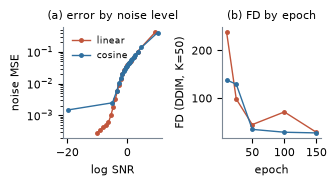

In [35]:
# Figure 4: (a) each seed-0 model's noise-prediction error against the noise level, section 9;
# (b) FD against training epochs, section 8.
fig, (ax_loss, ax_epoch) = plt.subplots(1, 2, figsize=(3.4, 1.9))
for name, colour in COLOURS.items():
    ax_loss.plot(log_snr[name], step_loss[name], "o-", color=colour, ms=2.5, lw=1.0, label=name)
    ax_epoch.plot(epoch_list, [epoch_scores[name, e]["fd"] for e in epoch_list], "o-",
                  color=colour, ms=2.5, lw=1.0)
ax_loss.set(xlabel="log SNR", ylabel="noise MSE", yscale="log", title="(a) error by noise level")
ax_epoch.set(xlabel="epoch", ylabel=f"FD (DDIM, K={EPOCH_STEPS})", title="(b) FD by epoch")
ax_loss.legend(frameon=False, fontsize=6.5)
plt.tight_layout()
fig.savefig("figure_4_mechanism.pdf", bbox_inches="tight")
plt.show()

## 12 Summary

The headline numbers in one machine-readable block.

In [36]:
# The headline numbers in one machine-readable block, rounded as printed above.
summary = {
    "n_eval": N_EVAL, "seeds": SEEDS, "floor": round(floor, 2),
    "real_accuracy": round(real_accuracy, 4),
    "grid_accuracy": {name: round(value, 4) for name, value in grid_accuracy.items()},
    "full_step_fd": {name: round(value, 2) for name, value in full_fd.items()},
    "winners": {sampler: {str(k): decisions[sampler, k]["winner"] for k in REDUCED}
                for sampler in SAMPLERS},
    "seconds_per_epoch": {name: round(value, 2) for name, value in seconds_per_epoch.items()}}
print(json.dumps(summary, indent=1))

{
 "n_eval": 1000,
 "seeds": [
  0,
  1,
  2
 ],
 "floor": 7.65,
 "real_accuracy": 0.9914,
 "grid_accuracy": {
  "linear": 0.9583,
  "cosine": 0.925
 },
 "full_step_fd": {
  "linear": 17.12,
  "cosine": 13.5
 },
 "winners": {
  "ddpm": {
   "10": "cosine",
   "20": "cosine",
   "50": "unclear",
   "100": "unclear",
   "250": "unclear"
  },
  "ddim": {
   "10": "unclear",
   "20": "unclear",
   "50": "unclear",
   "100": "unclear",
   "250": "unclear"
  }
 },
 "seconds_per_epoch": {
  "linear": 7.87,
  "cosine": 7.86
 }
}
